# ⚠️ GOOGLE COLAB SETUP\n\n**BEFORE RUNNING:** Make sure you have uploaded these files to Google Drive:\n```\nMy Drive/NLP_Phase5/\n├── label_shifted_fin_causality_dataset.csv\n└── multimodal_model_20260221_141142.pkl.zip\n```\n\n**Runtime Settings:**\n- Go to: Runtime → Change runtime type\n- Set: Hardware accelerator = GPU\n- Save\n\n---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mount Google Drive\nfrom google.colab import drive\ndrive.mount('/content/drive')\n\n# Verify files\nimport os\nBASE_PATH = '/content/drive/MyDrive/NLP_Phase5'\n\nrequired_files = [\n    f'{BASE_PATH}/label_shifted_fin_causality_dataset.csv',\n    f'{BASE_PATH}/multimodal_model_20260221_141142.pkl.zip'\n]\n\nprint('Checking files...')\nall_found = True\nfor file in required_files:\n    exists = os.path.exists(file)\n    print(f'  {os.path.basename(file)}: {'✅' if exists else '❌'}')\n    if not exists:\n        all_found = False\n\nif all_found:\n    print('\\n✅ All files found! Ready to proceed.')\nelse:\n    print(f'\\n❌ Missing files! Please upload to: {BASE_PATH}/')\n    raise FileNotFoundError('Required files not found in Google Drive')

In [ ]:
# Install required packages\n!pip install -q transformers==4.37.2 nltk accelerate>=0.20.0\n\n# Download NLTK data\nimport nltk\nnltk.download('wordnet', quiet=True)\nnltk.download('omw-1.4', quiet=True)\n\nprint('✅ Packages installed!')

---\n# Phase 5: Ablation & Robustness Analysis\n*(Original notebook content starts below)*

# Phase 5: Ablation & Robustness Analysis
## Systematic Evaluation of Model Components & Resilience

**Objective**: Quantify *each component's contribution* through ablation studies and evaluate *model resilience* under perturbations, noise, and distribution shifts.

### Ablation Studies
1. Component Ablation (Attention Pooling, Fusion Gate, Numerical Branch)
2. Feature Ablation (Individual numerical features)
3. Architectural Ablation (Text-only vs Multimodal vs Numerical-only)

### Robustness Tests
4. Text Perturbation (word dropout, character noise, synonym swap)
5. Numerical Perturbation (Gaussian noise at varying scales)
6. Temporal Distribution Shift (performance across time windows)
7. Adversarial Robustness (FGSM-style gradient attacks)
8. Input Length Sensitivity

## Section 1: Import Libraries & Load Trained Model

In [ ]:
import os, sys
print("Python:", sys.executable)
print("Conda prefix:", os.environ.get("CONDA_PREFIX"))
try:
    import numpy as np
    print("NumPy:", np.__version__)
except Exception as exc:
    print("NumPy import failed:", repr(exc))

Python: /usr/bin/python3
Conda prefix: None
NumPy: 2.0.2


In [ ]:
import os, sys, warnings, random, string, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, classification_report)
from tqdm.auto import tqdm

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# GPU check
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Memory: 15.64 GB


In [ ]:
import torch, platform
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("Platform:", platform.platform())

Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU count: 1
Platform: Linux-6.6.113+-x86_64-with-glibc2.35


In [ ]:
import torch, platform
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("Platform:", platform.platform())

Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU count: 1
Platform: Linux-6.6.113+-x86_64-with-glibc2.35


## Section 2: Model Architecture (Must Match Phase 3 Training)

In [ ]:
# ──────────────────────────────────────────────────
# Architecture definitions — identical to Phase 3
# ──────────────────────────────────────────────────

class AttentionPooling(nn.Module):
    """Learned attention pooling over token hidden states."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, hidden_states, attention_mask):
        scores = self.attention(hidden_states).squeeze(-1)
        scores = scores.masked_fill(~attention_mask.bool(), float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (hidden_states * weights).sum(dim=1)
        return pooled


class EnhancedMultimodalFinBERT(nn.Module):
    """Full multimodal model: FinBERT text + numerical features with gated fusion."""
    def __init__(self, base_model, num_numerical=3, dropout_rate=0.4):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size

        self.attention_pool = AttentionPooling(self.hidden_size)
        self.layer_norm = nn.LayerNorm(self.hidden_size)

        self.num_processor = nn.Sequential(
            nn.Linear(num_numerical, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(self.hidden_size + 32, self.hidden_size + 32),
            nn.Sigmoid()
        )

        combined_size = self.hidden_size + 32
        self.classifier = nn.Sequential(
            nn.Linear(combined_size, combined_size // 2),
            nn.LayerNorm(combined_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 2, combined_size // 4),
            nn.LayerNorm(combined_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 4, 2)
        )

        self._init_weights()

    def _init_weights(self):
        for module in [self.num_processor, self.classifier]:
            for layer in module:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def forward(self, input_ids, attention_mask, numerical):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.attention_pool(outputs.last_hidden_state, attention_mask)
        text_features = self.layer_norm(text_features)

        num_features = self.num_processor(numerical)

        combined = torch.cat((text_features, num_features), dim=1)
        gate = self.fusion_gate(combined)
        combined = combined * gate

        return self.classifier(combined)


# ── Text-only variant (for ablation) ──
class TextOnlyFinBERT(nn.Module):
    """Text-only model — no numerical features."""
    def __init__(self, base_model, dropout_rate=0.4):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size
        self.attention_pool = AttentionPooling(self.hidden_size)
        self.layer_norm = nn.LayerNorm(self.hidden_size)

        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_size, self.hidden_size // 2),
            nn.LayerNorm(self.hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.hidden_size // 2, self.hidden_size // 4),
            nn.LayerNorm(self.hidden_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.hidden_size // 4, 2)
        )

    def forward(self, input_ids, attention_mask, numerical=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.attention_pool(outputs.last_hidden_state, attention_mask)
        text_features = self.layer_norm(text_features)
        return self.classifier(text_features)


# ── Numerical-only variant (for ablation) ──
class NumericalOnlyClassifier(nn.Module):
    """Numerical-only baseline — no text."""
    def __init__(self, num_numerical=3, dropout_rate=0.4):
        super().__init__()
        self.processor = nn.Sequential(
            nn.Linear(num_numerical, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 2)
        )

    def forward(self, input_ids=None, attention_mask=None, numerical=None):
        return self.processor(numerical)


# ── No-Fusion-Gate variant ──
class MultimodalNoGate(nn.Module):
    """Multimodal model WITHOUT gated fusion — simple concatenation."""
    def __init__(self, base_model, num_numerical=3, dropout_rate=0.4):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size
        self.attention_pool = AttentionPooling(self.hidden_size)
        self.layer_norm = nn.LayerNorm(self.hidden_size)

        self.num_processor = nn.Sequential(
            nn.Linear(num_numerical, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )

        combined_size = self.hidden_size + 32
        self.classifier = nn.Sequential(
            nn.Linear(combined_size, combined_size // 2),
            nn.LayerNorm(combined_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 2, combined_size // 4),
            nn.LayerNorm(combined_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 4, 2)
        )

    def forward(self, input_ids, attention_mask, numerical):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.attention_pool(outputs.last_hidden_state, attention_mask)
        text_features = self.layer_norm(text_features)
        num_features = self.num_processor(numerical)
        combined = torch.cat((text_features, num_features), dim=1)  # No gate!
        return self.classifier(combined)


# ── No-Attention-Pooling variant (CLS only) ──
class MultimodalCLSPooling(nn.Module):
    """Multimodal model using CLS token instead of attention pooling."""
    def __init__(self, base_model, num_numerical=3, dropout_rate=0.4):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size
        self.layer_norm = nn.LayerNorm(self.hidden_size)

        self.num_processor = nn.Sequential(
            nn.Linear(num_numerical, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(self.hidden_size + 32, self.hidden_size + 32),
            nn.Sigmoid()
        )

        combined_size = self.hidden_size + 32
        self.classifier = nn.Sequential(
            nn.Linear(combined_size, combined_size // 2),
            nn.LayerNorm(combined_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 2, combined_size // 4),
            nn.LayerNorm(combined_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 4, 2)
        )

    def forward(self, input_ids, attention_mask, numerical):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = outputs.last_hidden_state[:, 0, :]  # CLS token only
        text_features = self.layer_norm(text_features)
        num_features = self.num_processor(numerical)
        combined = torch.cat((text_features, num_features), dim=1)
        gate = self.fusion_gate(combined)
        combined = combined * gate
        return self.classifier(combined)


print("All model architectures defined")

All model architectures defined


## Section 3: Load Data & Pre-trained Model

Detect Kaggle vs local, load dataset, scaler, tokeniser, and the trained Phase-3 checkpoint.

In [ ]:
# ─────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────
import os
import zipfile
import torch
import pandas as pd
from sklearn.preprocessing import RobustScaler
from transformers import AutoTokenizer, AutoModel

# ─────────────────────────────────────────────
# Paths (Local)
# ─────────────────────────────────────────────

# Dataset
DATA_PATH = r"/content/drive/MyDrive/label_shifted_fin_causality_dataset.csv"

# Model - load from zip and re-package properly
MODEL_ZIP = r"/content/drive/MyDrive/multimodal_model_20260221_141142.pkl.zip"
EXTRACT_DIR = r"/content/model_extracted"
RECONSTRUCTED_PKL = r"/content/multimodal_model_reconstructed.pkl"

# Unzip and reconstruct
if not os.path.exists(RECONSTRUCTED_PKL):
    # Extract if not already done
    if not os.path.exists(EXTRACT_DIR):
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        with zipfile.ZipFile(MODEL_ZIP, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print(f"✅ Extracted model to: {EXTRACT_DIR}")

    # Find the inner model folder
    inner_dirs = [d for d in os.listdir(EXTRACT_DIR)
                  if os.path.isdir(os.path.join(EXTRACT_DIR, d)) and 'multimodal' in d.lower()]

    if inner_dirs:
        model_dir = os.path.join(EXTRACT_DIR, inner_dirs[0])
        print(f"✅ Found model dir: {model_dir}")

        # Re-zip as proper PyTorch checkpoint
        with zipfile.ZipFile(RECONSTRUCTED_PKL, 'w', compression=zipfile.ZIP_STORED) as zf:
            for root, dirs, files in os.walk(model_dir):
                for file in files:
                    file_path = os.path.join(root, file)
                    # Archive name relative to extract dir, preserving structure
                    arcname = os.path.relpath(file_path, EXTRACT_DIR)
                    zf.write(file_path, arcname)

        print(f"✅ Reconstructed checkpoint: {RECONSTRUCTED_PKL}")
    else:
        raise FileNotFoundError(f"Cannot find model folder in {EXTRACT_DIR}")
else:
    print(f"✅ Using cached checkpoint: {RECONSTRUCTED_PKL}")

CHECKPOINT_PATH = RECONSTRUCTED_PKL

# ─────────────────────────────────────────────
# Load Dataset
# ─────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

NUMERICAL_COLS = ["return_t1", "return_t5", "volatility_5"]

# Temporal split (80 / 20)
split_date = df["date"].quantile(0.8)
train_df = df[df["date"] <= split_date].copy()
test_df  = df[df["date"] > split_date].copy()

# Shuffle train only
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Scale numerical features
scaler = RobustScaler()
train_df[NUMERICAL_COLS] = scaler.fit_transform(train_df[NUMERICAL_COLS])
test_df[NUMERICAL_COLS]  = scaler.transform(test_df[NUMERICAL_COLS])

print(f"\nTrain size: {len(train_df)} | Test size: {len(test_df)}")
print(f"Train range: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"Test range : {test_df['date'].min()} → {test_df['date'].max()}")

print("\nTrain label distribution:")
print(train_df["causal_label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_df["causal_label"].value_counts(normalize=True))

# ─────────────────────────────────────────────
# Tokenizer
# ─────────────────────────────────────────────
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 256

# ─────────────────────────────────────────────
# Load Model Checkpoint
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load checkpoint (now properly reconstructed)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

print("\n📊 Loaded checkpoint metadata:")
print(f"Accuracy : {checkpoint.get('accuracy', 'N/A')}")
print(f"F1-score : {checkpoint.get('f1_score', 'N/A')}")
print(f"AUC-ROC  : {checkpoint.get('auc_roc', 'N/A')}")

# ─────────────────────────────────────────────
# Rebuild Model Architecture
# ─────────────────────────────────────────────
base_model = AutoModel.from_pretrained(MODEL_NAME)

model = EnhancedMultimodalFinBERT(
    base_model=base_model,
    num_numerical=checkpoint.get("num_numerical", 3),
    dropout_rate=checkpoint.get("dropout_rate", 0.4),
).to(device)

# Load trained weights
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"\nDevice     : {device}")
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")
print("✅ Model loaded successfully!")

✅ Extracted model to: /content/model_extracted
✅ Found model dir: /content/model_extracted/multimodal_model_20260221_141142
✅ Reconstructed checkpoint: /content/multimodal_model_reconstructed.pkl

Train size: 29442 | Test size: 7230
Train range: 2000-11-27 00:00:00 → 2018-04-26 00:00:00
Test range : 2018-04-27 00:00:00 → 2025-04-30 00:00:00

Train label distribution:
causal_label
1    0.78551
0    0.21449
Name: proportion, dtype: float64

Test label distribution:
causal_label
1    0.683541
0    0.316459
Name: proportion, dtype: float64


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


📊 Loaded checkpoint metadata:
Accuracy : N/A
F1-score : N/A
AUC-ROC  : N/A


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Device     : cuda
Parameters : 110,824,987
✅ Model loaded successfully!


## Section 4: Dataset & DataLoader

In [ ]:
class MultimodalDataset(Dataset):
    """Tokenised text + scaled numerical features + label."""
    def __init__(self, dataframe, tokenizer, max_len, numerical_cols):
        self.texts = dataframe['clean_text'].fillna('').tolist()
        self.numericals = dataframe[numerical_cols].values.astype(np.float32)
        self.labels = dataframe['causal_label'].values.astype(np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'numerical': torch.tensor(self.numericals[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build datasets
BATCH_SIZE = 64  # Increased from 32 for faster training

train_dataset = MultimodalDataset(train_df, tokenizer, MAX_LEN, NUMERICAL_COLS)
test_dataset  = MultimodalDataset(test_df, tokenizer, MAX_LEN, NUMERICAL_COLS)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# For ablation training: split train into train/val (90/10)
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Weighted sampler for training (imbalanced classes)
train_labels = [train_dataset.labels[i] for i in train_subset.indices]
class_counts = np.bincount(train_labels)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
class_weights = (1.0 - beta) / (effective_num + 1e-8)
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train subset: {len(train_subset)} | Val subset: {len(val_subset)} | Test: {len(test_dataset)}")
print(f"Class distribution (train subset): {dict(zip(*np.unique(train_labels, return_counts=True)))}")

Train subset: 26498 | Val subset: 2944 | Test: 7230
Class distribution (train subset): {np.int64(0): np.int64(5697), np.int64(1): np.int64(20801)}


## Section 5: Baseline Evaluation (Full Model)

Evaluate the pre-trained Phase-3 multimodal model as the **baseline** for all comparisons.

In [ ]:
def evaluate_model(model, loader, device, desc="Evaluating"):
    """Evaluate any model variant and return metrics dict."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            numerical = batch['numerical'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, numerical)
            probs = torch.softmax(logits, dim=1)

            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'auc': auc,
        'preds': all_preds,
        'labels': all_labels,
        'probs': all_probs
    }

# ── Baseline evaluation ──
print("=" * 60)
print("BASELINE — Full Multimodal Model (Phase 3)")
print("=" * 60)
baseline_results = evaluate_model(model, test_loader, device, desc="Baseline")

print(f"  Accuracy:  {baseline_results['accuracy']:.4f}")
print(f"  F1 Score:  {baseline_results['f1']:.4f}")
print(f"  Precision: {baseline_results['precision']:.4f}")
print(f"  Recall:    {baseline_results['recall']:.4f}")
print(f"  AUC:       {baseline_results['auc']:.4f}")
print(f"\nClassification Report:")
print(classification_report(baseline_results['labels'], baseline_results['preds'],
                            target_names=['Non-Causal', 'Causal']))

# Store all results for comparison
ablation_results = {'Full Multimodal (Baseline)': {
    k: baseline_results[k] for k in ['accuracy', 'f1', 'precision', 'recall', 'auc']
}}

BASELINE — Full Multimodal Model (Phase 3)


Baseline:   0%|          | 0/113 [00:00<?, ?it/s]

  Accuracy:  0.8757
  F1 Score:  0.8781
  Precision: 0.8866
  Recall:    0.8757
  AUC:       0.9522

Classification Report:
              precision    recall  f1-score   support

  Non-Causal       0.76      0.89      0.82      2288
      Causal       0.95      0.87      0.91      4942

    accuracy                           0.88      7230
   macro avg       0.85      0.88      0.86      7230
weighted avg       0.89      0.88      0.88      7230



## Section 6: Feature Ablation (Zero-Out)

Measure the impact of each numerical feature by zeroing it out at inference time. A large drop indicates the feature is important.

In [ ]:
def evaluate_with_feature_ablation(model, loader, device, feature_idx_to_zero, feature_name):
    """Evaluate model with one numerical feature zeroed out."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Ablate {feature_name}", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            numerical = batch['numerical'].clone().to(device)
            labels = batch['label'].to(device)

            # Zero out the target feature
            numerical[:, feature_idx_to_zero] = 0.0

            logits = model(input_ids, attention_mask, numerical)
            probs = torch.softmax(logits, dim=1)

            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'auc': auc}


# ── Run feature ablation ──
print("=" * 60)
print("FEATURE ABLATION — Zeroing Individual Numerical Features")
print("=" * 60)

feature_ablation_results = {}
for idx, col in enumerate(NUMERICAL_COLS):
    res = evaluate_with_feature_ablation(model, test_loader, device, idx, col)
    feature_ablation_results[col] = res
    delta_f1 = res['f1'] - baseline_results['f1']
    delta_acc = res['accuracy'] - baseline_results['accuracy']
    print(f"\n  Without {col}:")
    print(f"    Acc: {res['accuracy']:.4f} (Δ={delta_acc:+.4f})  F1: {res['f1']:.4f} (Δ={delta_f1:+.4f})  AUC: {res['auc']:.4f}")

# Also zero ALL numerical features
def evaluate_zero_all_numerical(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Ablate ALL num", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            numerical = torch.zeros_like(batch['numerical']).to(device)
            labels = batch['label'].to(device)
            logits = model(input_ids, attention_mask, numerical)
            probs = torch.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'auc': auc}

res_zero_all = evaluate_zero_all_numerical(model, test_loader, device)
feature_ablation_results['ALL numerical'] = res_zero_all
delta_f1 = res_zero_all['f1'] - baseline_results['f1']
delta_acc = res_zero_all['accuracy'] - baseline_results['accuracy']
print(f"\n  Without ALL numerical features:")
print(f"    Acc: {res_zero_all['accuracy']:.4f} (Δ={delta_acc:+.4f})  F1: {res_zero_all['f1']:.4f} (Δ={delta_f1:+.4f})  AUC: {res_zero_all['auc']:.4f}")

# Store in main results
for col, res in feature_ablation_results.items():
    ablation_results[f'w/o {col}'] = res

FEATURE ABLATION — Zeroing Individual Numerical Features


Ablate return_t1:   0%|          | 0/113 [00:00<?, ?it/s]


  Without return_t1:
    Acc: 0.6838 (Δ=-0.1918)  F1: 0.6927 (Δ=-0.1854)  AUC: 0.8330


Ablate return_t5:   0%|          | 0/113 [00:00<?, ?it/s]


  Without return_t5:
    Acc: 0.8719 (Δ=-0.0037)  F1: 0.8740 (Δ=-0.0041)  AUC: 0.9438


Ablate volatility_5:   0%|          | 0/113 [00:00<?, ?it/s]


  Without volatility_5:
    Acc: 0.7992 (Δ=-0.0765)  F1: 0.7976 (Δ=-0.0805)  AUC: 0.8205


Ablate ALL num:   0%|          | 0/113 [00:00<?, ?it/s]


  Without ALL numerical features:
    Acc: 0.3537 (Δ=-0.5220)  F1: 0.2657 (Δ=-0.6124)  AUC: 0.5478


## Section 7: Training Utilities for Ablation Variants

Lightweight training loop with early stopping. We train ablation models for a limited number of epochs (ABLATION_EPOCHS = 5) to measure relative performance differences.

In [ ]:
ABLATION_EPOCHS = 3  # Reduced from 5 for faster experimentation
PATIENCE = 2

class EarlyStopping:
    def __init__(self, patience=2, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def train_ablation_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=ABLATION_EPOCHS,
    patience=PATIENCE,
    model_name="ablation"
):
    """Train an ablation variant with mixed precision for faster training."""

    # Separate BERT and head parameters
    bert_params, head_params = [], []
    for name, param in model.named_parameters():
        if 'bert' in name:
            bert_params.append(param)
        else:
            head_params.append(param)

    optimizer = torch.optim.AdamW(
        [
            {'params': bert_params, 'lr': 1e-5, 'weight_decay': 0.01},
            {'params': head_params, 'lr': 5e-5, 'weight_decay': 0.01},
        ]
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    early_stop = EarlyStopping(patience=patience)

    # Mixed precision training
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

    best_model_state = None
    best_val_f1 = 0.0

    print(f"Training config: ABLATION_EPOCHS={epochs}, PATIENCE={patience}")

    for epoch in range(epochs):

        # ── Train ──
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch in tqdm(
            train_loader,
            desc=f"[{model_name}] Epoch {epoch+1}/{epochs}",
            leave=False
        ):
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            numerical = batch['numerical'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)

            optimizer.zero_grad()

            if scaler:
                with torch.cuda.amp.autocast():
                    logits = model(input_ids, attention_mask, numerical)
                    loss = criterion(logits, labels)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(input_ids, attention_mask, numerical)
                loss = criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()

        train_loss = total_loss / total
        train_acc = correct / total

        # ── Validate ──
        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                numerical = batch['numerical'].to(device)
                labels = batch['label'].to(device)

                logits = model(input_ids, attention_mask, numerical)
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_labels, val_preds, average='weighted')
        val_acc = accuracy_score(val_labels, val_preds)

        print(
            f"Epoch {epoch+1}: "
            f"train_loss={train_loss:.4f}  "
            f"train_acc={train_acc:.4f}  "
            f"val_acc={val_acc:.4f}  "
            f"val_f1={val_f1:.4f}"
        )

        # ── Save best model ──
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {
                k: v.clone() for k, v in model.state_dict().items()
            }

        # ── Early stopping ──
        early_stop(val_f1)
        if early_stop.should_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # ── Restore best model ──
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, best_val_f1

## Section 8: Component Ablation — Train & Evaluate Variants

Train four architectural ablation variants:
1. **Text-Only** — removes the numerical branch entirely
2. **Numerical-Only** — removes FinBERT entirely (lightweight MLP on 3 features)
3. **No Fusion Gate** — simple concatenation instead of gated fusion
4. **CLS Pooling** — uses CLS token instead of learned attention pooling

Each variant is trained for up to 5 epochs and evaluated on the same test set.

In [ ]:
ablation_variants = {
    'Text-Only': lambda: TextOnlyFinBERT(
        AutoModel.from_pretrained(MODEL_NAME), dropout_rate=0.4
    ),
    'Numerical-Only': lambda: NumericalOnlyClassifier(
        num_numerical=3, dropout_rate=0.4
    ),
    'No Fusion Gate': lambda: MultimodalNoGate(
        AutoModel.from_pretrained(MODEL_NAME), num_numerical=3, dropout_rate=0.4
    ),
    'CLS Pooling': lambda: MultimodalCLSPooling(
        AutoModel.from_pretrained(MODEL_NAME), num_numerical=3, dropout_rate=0.4
    ),
}

component_results = {}

for name, build_fn in ablation_variants.items():
    print("\n" + "=" * 60)
    print(f"TRAINING: {name}")
    print("=" * 60)

    variant_model = build_fn().to(device)
    param_count = sum(p.numel() for p in variant_model.parameters())
    print(f"  Parameters: {param_count:,}")

    variant_model, best_val_f1 = train_ablation_model(
        variant_model, train_loader, val_loader, device, model_name=name
    )
    print(f"  Best val F1: {best_val_f1:.4f}")

    # Evaluate on test set
    test_res = evaluate_model(variant_model, test_loader, device, desc=f"Test {name}")
    component_results[name] = {k: test_res[k] for k in ['accuracy', 'f1', 'precision', 'recall', 'auc']}
    component_results[name]['params'] = param_count

    delta_f1 = test_res['f1'] - baseline_results['f1']
    delta_acc = test_res['accuracy'] - baseline_results['accuracy']
    print(f"  Test Acc: {test_res['accuracy']:.4f} (Δ={delta_acc:+.4f})")
    print(f"  Test F1:  {test_res['f1']:.4f} (Δ={delta_f1:+.4f})")
    print(f"  Test AUC: {test_res['auc']:.4f}")

    # Store in main results
    ablation_results[name] = component_results[name]

    # Free GPU memory
    del variant_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\n✓ All component ablation variants trained and evaluated.")


TRAINING: Text-Only


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Parameters: 110,150,211
Training config: ABLATION_EPOCHS=3, PATIENCE=2


[Text-Only] Epoch 1/3:   0%|          | 0/415 [00:00<?, ?it/s]

...

Epoch 2: train_loss=0.2612  train_acc=0.9648  val_acc=0.9772  val_f1=0.9773


[CLS Pooling] Epoch 3/3:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch 3: train_loss=0.2372  train_acc=0.9800  val_acc=0.9769  val_f1=0.9772
  Best val F1: 0.9773


Test CLS Pooling:   0%|          | 0/113 [00:00<?, ?it/s]

  Test Acc: 0.8011 (Δ=-0.0746)
  Test F1:  0.7896 (Δ=-0.0886)
  Test AUC: 0.9061

✓ All component ablation variants trained and evaluated.


## Section 9: Ablation Results Visualization

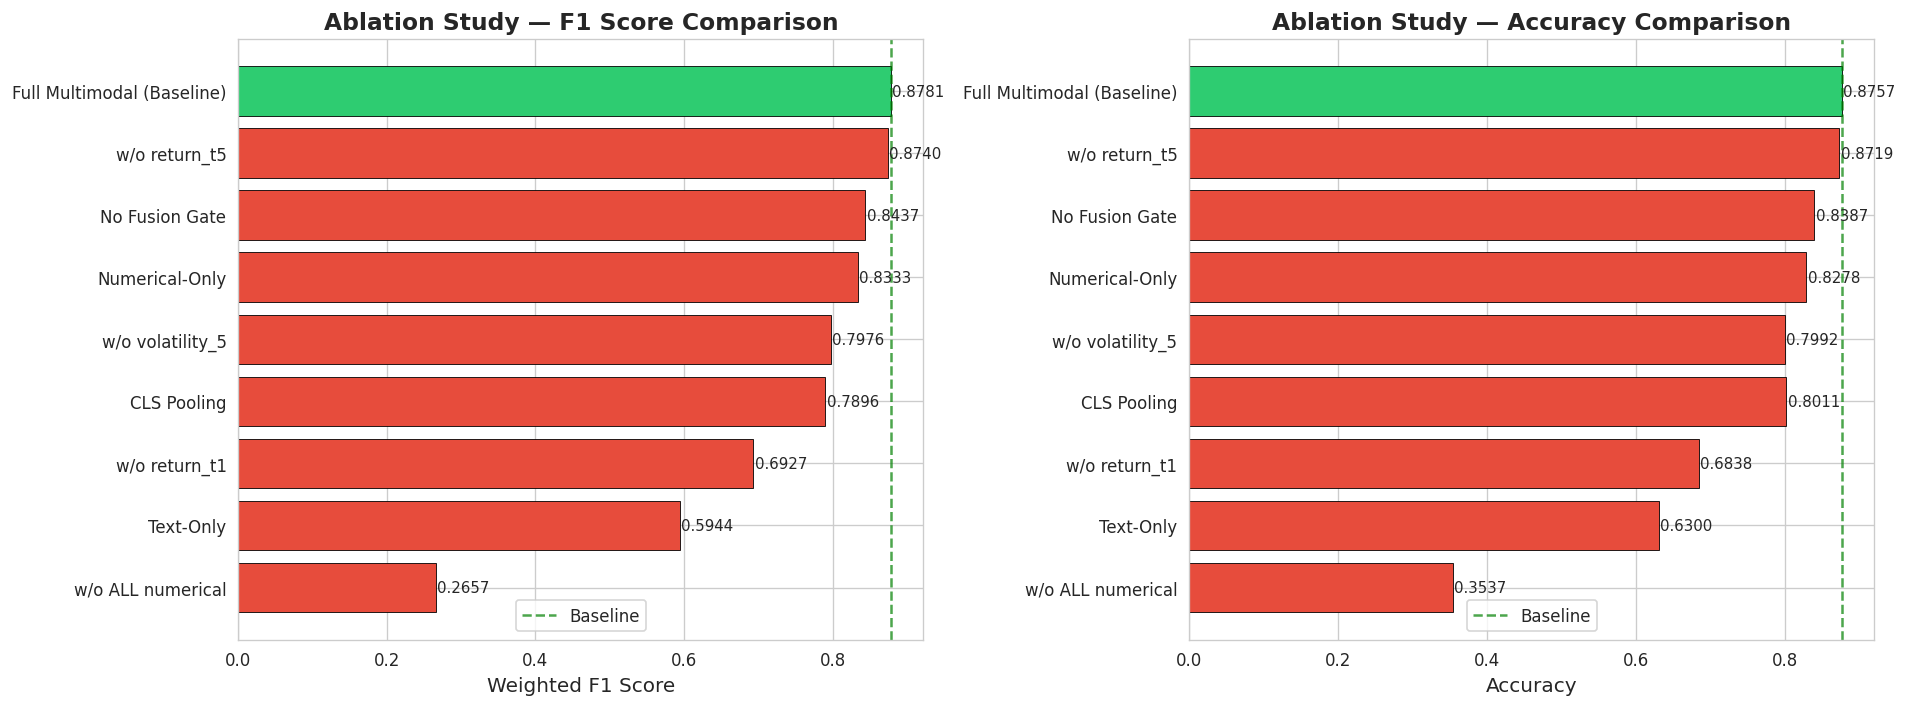


📊 Ablation Summary Table
                            accuracy     f1  precision  recall    auc
w/o ALL numerical             0.3537 0.2657     0.5745  0.3537 0.5478
Text-Only                     0.6300 0.5944     0.5818  0.6300 0.5703
w/o return_t1                 0.6838 0.6927     0.7967  0.6838 0.8330
CLS Pooling                   0.8011 0.7896     0.7971  0.8011 0.9061
w/o volatility_5              0.7992 0.7976     0.7965  0.7992 0.8205
Numerical-Only                0.8278 0.8333     0.8638  0.8278 0.9280
No Fusion Gate                0.8387 0.8437     0.8701  0.8387 0.9170
w/o return_t5                 0.8719 0.8740     0.8799  0.8719 0.9438
Full Multimodal (Baseline)    0.8757 0.8781     0.8866  0.8757 0.9522

📉 Delta from Baseline
                   accuracy      f1  precision  recall     auc
w/o ALL numerical   -0.5220 -0.6124    -0.3121 -0.5220 -0.4044
Text-Only           -0.2456 -0.2837    -0.3048 -0.2456 -0.3819
w/o return_t1       -0.1918 -0.1854    -0.0899 -0.1918 -0.1192

In [ ]:
# ── Ablation comparison bar chart ──
results_df = pd.DataFrame(ablation_results).T
results_df = results_df[['accuracy', 'f1', 'precision', 'recall', 'auc']]
results_df = results_df.sort_values('f1', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 comparison
colors = ['#2ecc71' if idx == 'Full Multimodal (Baseline)' else '#e74c3c' if results_df.loc[idx, 'f1'] < baseline_results['f1'] else '#3498db'
          for idx in results_df.index]
bars = axes[0].barh(results_df.index, results_df['f1'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=baseline_results['f1'], color='green', linestyle='--', alpha=0.7, label='Baseline')
axes[0].set_xlabel('Weighted F1 Score', fontsize=12)
axes[0].set_title('Ablation Study — F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, results_df['f1']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

# Accuracy comparison
colors2 = ['#2ecc71' if idx == 'Full Multimodal (Baseline)' else '#e74c3c' if results_df.loc[idx, 'accuracy'] < baseline_results['accuracy'] else '#3498db'
           for idx in results_df.index]
bars2 = axes[1].barh(results_df.index, results_df['accuracy'], color=colors2, edgecolor='black', linewidth=0.5)
axes[1].axvline(x=baseline_results['accuracy'], color='green', linestyle='--', alpha=0.7, label='Baseline')
axes[1].set_xlabel('Accuracy', fontsize=12)
axes[1].set_title('Ablation Study — Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
for bar, val in zip(bars2, results_df['accuracy']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary table ──
print("\n📊 Ablation Summary Table")
print("=" * 80)
print(results_df.to_string(float_format='{:.4f}'.format))

# ── Delta table (relative to baseline) ──
delta_df = results_df.copy()
for col in delta_df.columns:
    delta_df[col] = delta_df[col] - ablation_results['Full Multimodal (Baseline)'][col]
# Remove baseline row (all zeros)
delta_df = delta_df.drop('Full Multimodal (Baseline)', errors='ignore')
print("\n📉 Delta from Baseline")
print("=" * 80)
print(delta_df.to_string(float_format='{:+.4f}'.format))

---
# Part B: Robustness Analysis

## Section 10: Text Perturbation Functions

Define four common text perturbation strategies to test model robustness:
- **Word Dropout**: Randomly drop words
- **Character Noise**: Swap random characters
- **Word Shuffle**: Shuffle word order
- **Synonym Replacement**: Replace words with synonyms (via WordNet)

In [ ]:
import nltk
try:
    from nltk.corpus import wordnet
    wordnet.synsets('test')  # trigger download check
except LookupError:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    from nltk.corpus import wordnet

import random
import string

def word_dropout(text, rate=0.1):
    """Randomly drop words from text."""
    words = text.split()
    if len(words) <= 1:
        return text
    kept = [w for w in words if random.random() > rate]
    return ' '.join(kept) if kept else words[0]

def char_noise(text, rate=0.05):
    """Randomly replace characters with random letters."""
    chars = list(text)
    for i in range(len(chars)):
        if chars[i].isalpha() and random.random() < rate:
            chars[i] = random.choice(string.ascii_lowercase)
    return ''.join(chars)

def word_shuffle(text, rate=0.2):
    """Randomly swap adjacent words."""
    words = text.split()
    n_swaps = max(1, int(len(words) * rate))
    for _ in range(n_swaps):
        if len(words) < 2:
            break
        idx = random.randint(0, len(words) - 2)
        words[idx], words[idx + 1] = words[idx + 1], words[idx]
    return ' '.join(words)

def synonym_replace(text, rate=0.1):
    """Replace random words with WordNet synonyms."""
    words = text.split()
    new_words = []
    for w in words:
        if random.random() < rate:
            synsets = wordnet.synsets(w)
            if synsets:
                synonyms = set()
                for syn in synsets[:3]:
                    for lemma in syn.lemmas():
                        if lemma.name() != w and '_' not in lemma.name():
                            synonyms.add(lemma.name())
                if synonyms:
                    new_words.append(random.choice(list(synonyms)))
                    continue
        new_words.append(w)
    return ' '.join(new_words)

print("Text perturbation functions defined")
# Demo
sample = "Tesla stock plummeted after the earnings report disappointed investors"
print(f"\nOriginal:   {sample}")
print(f"Word drop:  {word_dropout(sample, 0.3)}")
print(f"Char noise: {char_noise(sample, 0.1)}")
print(f"Word shuf:  {word_shuffle(sample, 0.3)}")
print(f"Synonym:    {synonym_replace(sample, 0.3)}")

Text perturbation functions defined

Original:   Tesla stock plummeted after the earnings report disappointed investors
Word drop:  Tesla stock plummeted after the earnings report
Char noise: nesxa stock ptpmleted pfter ghe earvings meposh disappoiized invqstors
Word shuf:  Tesla stock after plummeted the earnings disappointed report investors
Synonym:    Tesla stock plummeted after the earnings study disappointed investors


## Section 11: Text Perturbation Robustness Experiments

Apply each perturbation at increasing rates and measure F1 degradation.

In [ ]:
class PerturbedTextDataset(Dataset):
    """Apply a text perturbation function to the dataset on-the-fly."""
    def __init__(self, dataframe, tokenizer, max_len, numerical_cols, perturb_fn, perturb_rate):
        self.texts = dataframe['clean_text'].fillna('').tolist()
        self.numericals = dataframe[numerical_cols].values.astype(np.float32)
        self.labels = dataframe['causal_label'].values.astype(np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.perturb_fn = perturb_fn
        self.perturb_rate = perturb_rate

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.perturb_fn(self.texts[idx], self.perturb_rate)
        enc = self.tokenizer(text, max_length=self.max_len, padding='max_length',
                             truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'numerical': torch.tensor(self.numericals[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Run text perturbation experiments ──
perturbation_fns = {
    'Word Dropout': word_dropout,
    'Char Noise': char_noise,
    'Word Shuffle': word_shuffle,
    'Synonym Replace': synonym_replace,
}

perturbation_rates = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
text_robustness_results = {}

random.seed(42)

for fn_name, fn in perturbation_fns.items():
    print(f"\n{'='*50}")
    print(f"Text Perturbation: {fn_name}")
    print(f"{'='*50}")
    rate_results = {}

    for rate in perturbation_rates:
        if rate == 0.0:
            # Use baseline results
            rate_results[rate] = {
                'accuracy': baseline_results['accuracy'],
                'f1': baseline_results['f1'],
                'auc': baseline_results['auc']
            }
            print(f"  Rate {rate:.2f}: F1={baseline_results['f1']:.4f} (baseline)")
            continue

        perturbed_ds = PerturbedTextDataset(test_df, tokenizer, MAX_LEN, NUMERICAL_COLS, fn, rate)
        perturbed_loader = DataLoader(perturbed_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

        res = evaluate_model(model, perturbed_loader, device, desc=f"{fn_name} r={rate}")
        rate_results[rate] = {'accuracy': res['accuracy'], 'f1': res['f1'], 'auc': res['auc']}
        delta = res['f1'] - baseline_results['f1']
        print(f"  Rate {rate:.2f}: F1={res['f1']:.4f} (Δ={delta:+.4f})  Acc={res['accuracy']:.4f}")

    text_robustness_results[fn_name] = rate_results

print("\n✓ Text perturbation robustness analysis complete.")


Text Perturbation: Word Dropout
  Rate 0.00: F1=0.8781 (baseline)


Word Dropout r=0.05:   0%|          | 0/113 [00:00<?, ?it/s]

  Rate 0.05: F1=0.8796 (Δ=+0.0015)  Acc=0.8773


Word Dropout r=0.1:   0%|          | 0/113 [00:00<?, ?it/s]

  Rate 0.10: F1=0.8785 (Δ=+0.0003)  Acc=0.8763


...

  Rate 0.20: F1=0.8731 (Δ=-0.0050)  Acc=0.8714


Synonym Replace r=0.3:   0%|          | 0/113 [00:00<?, ?it/s]

  Rate 0.30: F1=0.8722 (Δ=-0.0059)  Acc=0.8710


Synonym Replace r=0.5:   0%|          | 0/113 [00:00<?, ?it/s]

  Rate 0.50: F1=0.8663 (Δ=-0.0118)  Acc=0.8667

✓ Text perturbation robustness analysis complete.


## Section 12: Numerical Feature Robustness (Gaussian Noise)

Inject Gaussian noise into scaled numerical features at increasing standard deviations (σ) to test sensitivity.

In [ ]:
def evaluate_with_numerical_noise(model, loader, device, noise_std):
    """Evaluate model with Gaussian noise added to numerical features."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Noise σ={noise_std:.1f}", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            numerical = batch['numerical'].to(device)
            labels = batch['label'].to(device)

            # Add Gaussian noise
            noise = torch.randn_like(numerical) * noise_std
            noisy_numerical = numerical + noise

            logits = model(input_ids, attention_mask, noisy_numerical)
            probs = torch.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return {'accuracy': acc, 'f1': f1, 'auc': auc}

# ── Run numerical noise experiments ──
noise_stds = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 3.0]
numerical_robustness = {}

print("=" * 50)
print("NUMERICAL ROBUSTNESS — Gaussian Noise Injection")
print("=" * 50)

for sigma in noise_stds:
    if sigma == 0.0:
        numerical_robustness[sigma] = {
            'accuracy': baseline_results['accuracy'],
            'f1': baseline_results['f1'],
            'auc': baseline_results['auc']
        }
        print(f"  σ={sigma:.2f}: F1={baseline_results['f1']:.4f} (baseline)")
    else:
        torch.manual_seed(42)
        res = evaluate_with_numerical_noise(model, test_loader, device, sigma)
        numerical_robustness[sigma] = res
        delta = res['f1'] - baseline_results['f1']
        print(f"  σ={sigma:.2f}: F1={res['f1']:.4f} (Δ={delta:+.4f})  Acc={res['accuracy']:.4f}")

print("\n✓ Numerical noise robustness analysis complete.")

NUMERICAL ROBUSTNESS — Gaussian Noise Injection
  σ=0.00: F1=0.8781 (baseline)


Noise σ=0.1:   0%|          | 0/113 [00:00<?, ?it/s]

  σ=0.10: F1=0.8544 (Δ=-0.0237)  Acc=0.8521


Noise σ=0.2:   0%|          | 0/113 [00:00<?, ?it/s]

  σ=0.25: F1=0.8059 (Δ=-0.0722)  Acc=0.8040


...

  σ=1.00: F1=0.6609 (Δ=-0.2172)  Acc=0.6766


Noise σ=2.0:   0%|          | 0/113 [00:00<?, ?it/s]

  σ=2.00: F1=0.6217 (Δ=-0.2565)  Acc=0.6474


Noise σ=3.0:   0%|          | 0/113 [00:00<?, ?it/s]

  σ=3.00: F1=0.6038 (Δ=-0.2744)  Acc=0.6342

✓ Numerical noise robustness analysis complete.


## Section 13: Adversarial Robustness — FGSM Attack on Numerical Features

Apply Fast Gradient Sign Method (FGSM) to perturb numerical features in the direction that maximises loss.

In [23]:
def fgsm_attack_numerical(model, loader, device, epsilon):
    """FGSM attack on numerical features only."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(loader, desc=f"FGSM ε={epsilon:.2f}", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        numerical = batch['numerical'].to(device)
        labels = batch['label'].to(device)

        numerical.requires_grad_(True)

        logits = model(input_ids, attention_mask, numerical)
        loss = criterion(logits, labels)
        loss.backward()

        # FGSM perturbation
        perturbation = epsilon * numerical.grad.sign()
        adv_numerical = numerical + perturbation

        with torch.no_grad():
            adv_logits = model(input_ids, attention_mask, adv_numerical)
            probs = torch.softmax(adv_logits, dim=1)
            all_preds.extend(adv_logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

        numerical.requires_grad_(False)

    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return {'accuracy': acc, 'f1': f1, 'auc': auc}

# ── Run FGSM attack at various epsilon levels ──
epsilons = [0.0, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
fgsm_results = {}

print("=" * 50)
print("ADVERSARIAL ROBUSTNESS — FGSM on Numerical Features")
print("=" * 50)

for eps in epsilons:
    if eps == 0.0:
        fgsm_results[eps] = {
            'accuracy': baseline_results['accuracy'],
            'f1': baseline_results['f1'],
            'auc': baseline_results['auc']
        }
        print(f"  ε={eps:.2f}: F1={baseline_results['f1']:.4f} (baseline)")
    else:
        res = fgsm_attack_numerical(model, test_loader, device, eps)
        fgsm_results[eps] = res
        delta = res['f1'] - baseline_results['f1']
        print(f"  ε={eps:.2f}: F1={res['f1']:.4f} (Δ={delta:+.4f})  Acc={res['accuracy']:.4f}")

print("\n✓ FGSM adversarial robustness analysis complete.")

ADVERSARIAL ROBUSTNESS — FGSM on Numerical Features
  ε=0.00: F1=0.8781 (baseline)


FGSM ε=0.01:   0%|          | 0/113 [00:00<?, ?it/s]

  ε=0.01: F1=0.8635 (Δ=-0.0146)  Acc=0.8611


FGSM ε=0.05:   0%|          | 0/113 [00:00<?, ?it/s]

  ε=0.05: F1=0.8222 (Δ=-0.0559)  Acc=0.8194


...

  ε=0.25: F1=0.5745 (Δ=-0.3036)  Acc=0.5694


FGSM ε=0.50:   0%|          | 0/113 [00:00<?, ?it/s]

  ε=0.50: F1=0.4516 (Δ=-0.4265)  Acc=0.4564


FGSM ε=1.00:   0%|          | 0/113 [00:00<?, ?it/s]

  ε=1.00: F1=0.4499 (Δ=-0.4282)  Acc=0.4845

✓ FGSM adversarial robustness analysis complete.


## Section 14: Temporal Distribution Shift

Split the test set by year to analyse how the model performs across different time periods (potential distribution shift).

In [25]:
# ── Detect date column ──
date_col = None
for col in ['date', 'Date', 'publish_date', 'published_date', 'timestamp']:
    if col in df.columns:
        date_col = col
        break

temporal_results = {}

if date_col:
    # Ensure datetime
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # Use detected date column
    test_df_orig = df[df[date_col] > split_date].copy()
    test_df_orig["_year"] = test_df_orig[date_col].dt.year

    print("=" * 50)
    print("TEMPORAL DISTRIBUTION SHIFT")
    print("=" * 50)
    print(f"Date column: {date_col}")
    print("Year distribution in test set:")
    print(test_df_orig["_year"].value_counts().sort_index().to_string())

    for year in sorted(test_df_orig["_year"].dropna().unique()):
        year = int(year)
        year_df = test_df_orig[test_df_orig["_year"] == year]

        if len(year_df) < 20:
            print(f"  Year {year}: only {len(year_df)} samples — skipping")
            continue

        year_df = year_df.reset_index(drop=True)

        year_ds = MultimodalDataset(
            year_df,
            tokenizer,
            MAX_LEN,
            NUMERICAL_COLS
        )

        year_loader = DataLoader(
            year_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0
        )

        res = evaluate_model(
            model,
            year_loader,
            device,
            desc=f"Year {year}"
        )

        temporal_results[year] = {
            "accuracy": res["accuracy"],
            "f1": res["f1"],
            "auc": res["auc"],
            "n_samples": len(year_df)
        }

        print(
            f"  Year {year} (n={len(year_df)}): "
            f"Acc={res['accuracy']:.4f}  "
            f"F1={res['f1']:.4f}  "
            f"AUC={res['auc']:.4f}"
        )

else:
    print("⚠ No date column found — skipping temporal analysis.")
    print("Available columns:", list(df.columns[:10]))

print("\n✓ Temporal distribution shift analysis complete.")

TEMPORAL DISTRIBUTION SHIFT
Date column: date
Year distribution in test set:
_year
2018    7203
2019      18
2020       1
2023       7
2025       1


Year 2018:   0%|          | 0/113 [00:00<?, ?it/s]

  Year 2018 (n=7203): Acc=0.4108  F1=0.3591  AUC=0.5863
  Year 2019: only 18 samples — skipping
  Year 2020: only 1 samples — skipping
  Year 2023: only 7 samples — skipping
  Year 2025: only 1 samples — skipping

✓ Temporal distribution shift analysis complete.


## Section 15: Input Length Sensitivity

Bucket test samples by text length and evaluate per-bucket performance to detect length bias.

In [26]:
# ── Bucket test samples by word count ──
test_df['_word_count'] = test_df['clean_text'].fillna('').str.split().str.len()
length_bins = [0, 20, 50, 100, 150, 200, 500, float('inf')]
length_labels_str = ['<20', '20-50', '50-100', '100-150', '150-200', '200-500', '500+']
test_df['_length_bin'] = pd.cut(test_df['_word_count'], bins=length_bins, labels=length_labels_str, right=False)

length_results = {}

print("=" * 50)
print("INPUT LENGTH SENSITIVITY")
print("=" * 50)
print(f"Length distribution in test set:")
print(test_df['_length_bin'].value_counts().sort_index().to_string())
print()

for bin_label in length_labels_str:
    mask = test_df['_length_bin'] == bin_label
    n_samples = mask.sum()
    if n_samples < 20:
        print(f"  {bin_label} words (n={n_samples}): too few — skipping")
        continue

    bin_df = test_df.loc[mask].reset_index(drop=True)
    bin_ds = MultimodalDataset(bin_df, tokenizer, MAX_LEN, NUMERICAL_COLS)
    bin_loader = DataLoader(bin_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    res = evaluate_model(model, bin_loader, device, desc=f"Len {bin_label}")
    length_results[bin_label] = {
        'accuracy': res['accuracy'], 'f1': res['f1'], 'auc': res['auc'], 'n_samples': n_samples
    }
    print(f"  {bin_label} words (n={n_samples}): Acc={res['accuracy']:.4f}  F1={res['f1']:.4f}  AUC={res['auc']:.4f}")

# Cleanup temp columns
test_df.drop(columns=['_word_count', '_length_bin'], inplace=True, errors='ignore')

print("\n✓ Input length sensitivity analysis complete.")

INPUT LENGTH SENSITIVITY
Length distribution in test set:
_length_bin
<20           0
20-50         0
50-100      119
100-150     263
150-200     123
200-500    2955
500+       3770

  <20 words (n=0): too few — skipping
  20-50 words (n=0): too few — skipping


Len 50-100:   0%|          | 0/2 [00:00<?, ?it/s]

  50-100 words (n=119): Acc=0.9832  F1=0.9832  AUC=0.9985


Len 100-150:   0%|          | 0/5 [00:00<?, ?it/s]

  100-150 words (n=263): Acc=0.9886  F1=0.9886  AUC=0.9784


...

  150-200 words (n=123): Acc=0.9431  F1=0.9434  AUC=0.9725


Len 200-500:   0%|          | 0/47 [00:00<?, ?it/s]

  200-500 words (n=2955): Acc=0.8386  F1=0.8421  AUC=0.9246


Len 500+:   0%|          | 0/59 [00:00<?, ?it/s]

  500+ words (n=3770): Acc=0.8912  F1=0.8937  AUC=0.9690

✓ Input length sensitivity analysis complete.


## Section 16: Robustness Sensitivity Curves

Four-panel plot showing how F1 degrades under each perturbation type and intensity.

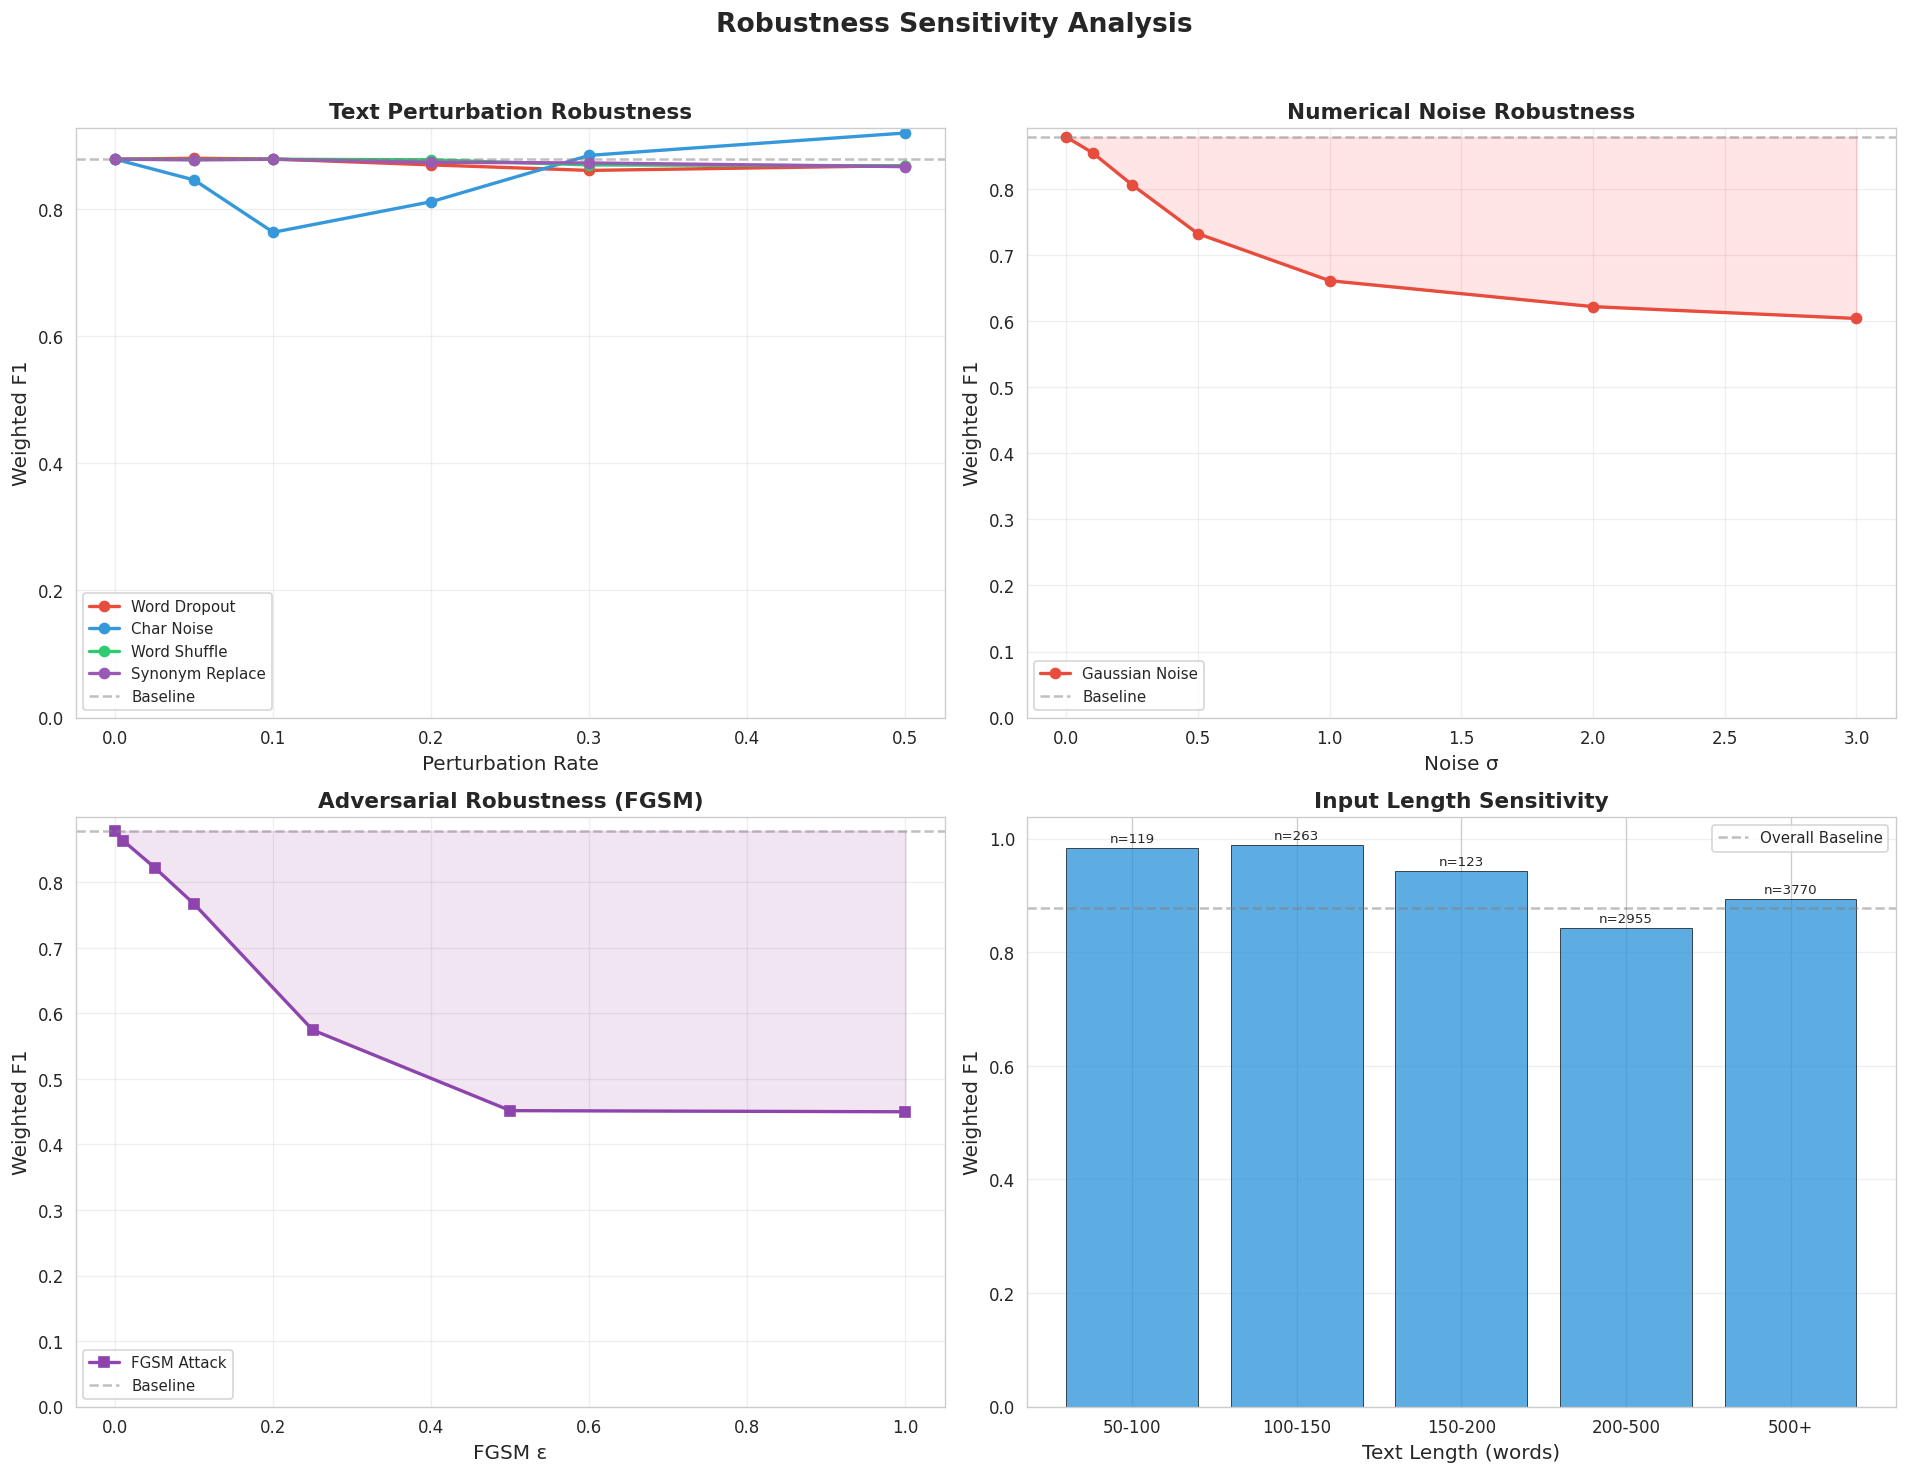

Saved: robustness_sensitivity_curves.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Robustness Sensitivity Analysis', fontsize=16, fontweight='bold', y=1.02)

# ── Panel 1: Text Perturbation ──
ax = axes[0, 0]
colors_text = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for i, (fn_name, rate_res) in enumerate(text_robustness_results.items()):
    rates = sorted(rate_res.keys())
    f1s = [rate_res[r]['f1'] for r in rates]
    ax.plot(rates, f1s, 'o-', label=fn_name, color=colors_text[i], linewidth=2, markersize=6)
ax.axhline(y=baseline_results['f1'], color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.set_xlabel('Perturbation Rate', fontsize=12)
ax.set_ylabel('Weighted F1', fontsize=12)
ax.set_title('Text Perturbation Robustness', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# ── Panel 2: Numerical Noise ──
ax = axes[0, 1]
sigmas = sorted(numerical_robustness.keys())
f1s_noise = [numerical_robustness[s]['f1'] for s in sigmas]
ax.plot(sigmas, f1s_noise, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='Gaussian Noise')
ax.axhline(y=baseline_results['f1'], color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.fill_between(sigmas, f1s_noise, baseline_results['f1'], alpha=0.1, color='red')
ax.set_xlabel('Noise σ', fontsize=12)
ax.set_ylabel('Weighted F1', fontsize=12)
ax.set_title('Numerical Noise Robustness', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# ── Panel 3: FGSM Attack ──
ax = axes[1, 0]
eps_vals = sorted(fgsm_results.keys())
f1s_fgsm = [fgsm_results[e]['f1'] for e in eps_vals]
ax.plot(eps_vals, f1s_fgsm, 's-', color='#8e44ad', linewidth=2, markersize=6, label='FGSM Attack')
ax.axhline(y=baseline_results['f1'], color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.fill_between(eps_vals, f1s_fgsm, baseline_results['f1'], alpha=0.1, color='purple')
ax.set_xlabel('FGSM ε', fontsize=12)
ax.set_ylabel('Weighted F1', fontsize=12)
ax.set_title('Adversarial Robustness (FGSM)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# ── Panel 4: Input Length Sensitivity ──
ax = axes[1, 1]
if length_results:
    bins_sorted = list(length_results.keys())
    f1s_len = [length_results[b]['f1'] for b in bins_sorted]
    n_samples = [length_results[b]['n_samples'] for b in bins_sorted]
    bars = ax.bar(bins_sorted, f1s_len, color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.axhline(y=baseline_results['f1'], color='gray', linestyle='--', alpha=0.5, label='Overall Baseline')
    # Annotate with sample counts
    for bar, n, f in zip(bars, n_samples, f1s_len):
        ax.text(bar.get_x() + bar.get_width()/2, f + 0.005, f'n={n}',
                ha='center', va='bottom', fontsize=8)
    ax.set_xlabel('Text Length (words)', fontsize=12)
    ax.set_ylabel('Weighted F1', fontsize=12)
    ax.set_title('Input Length Sensitivity', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(bottom=0)
else:
    ax.text(0.5, 0.5, 'No length data', transform=ax.transAxes, ha='center', fontsize=14)

plt.tight_layout()
plt.savefig('robustness_sensitivity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: robustness_sensitivity_curves.png")

## Section 17: Comprehensive Robustness Heatmap

Unified heatmap showing F1 scores across all perturbation types and intensities.

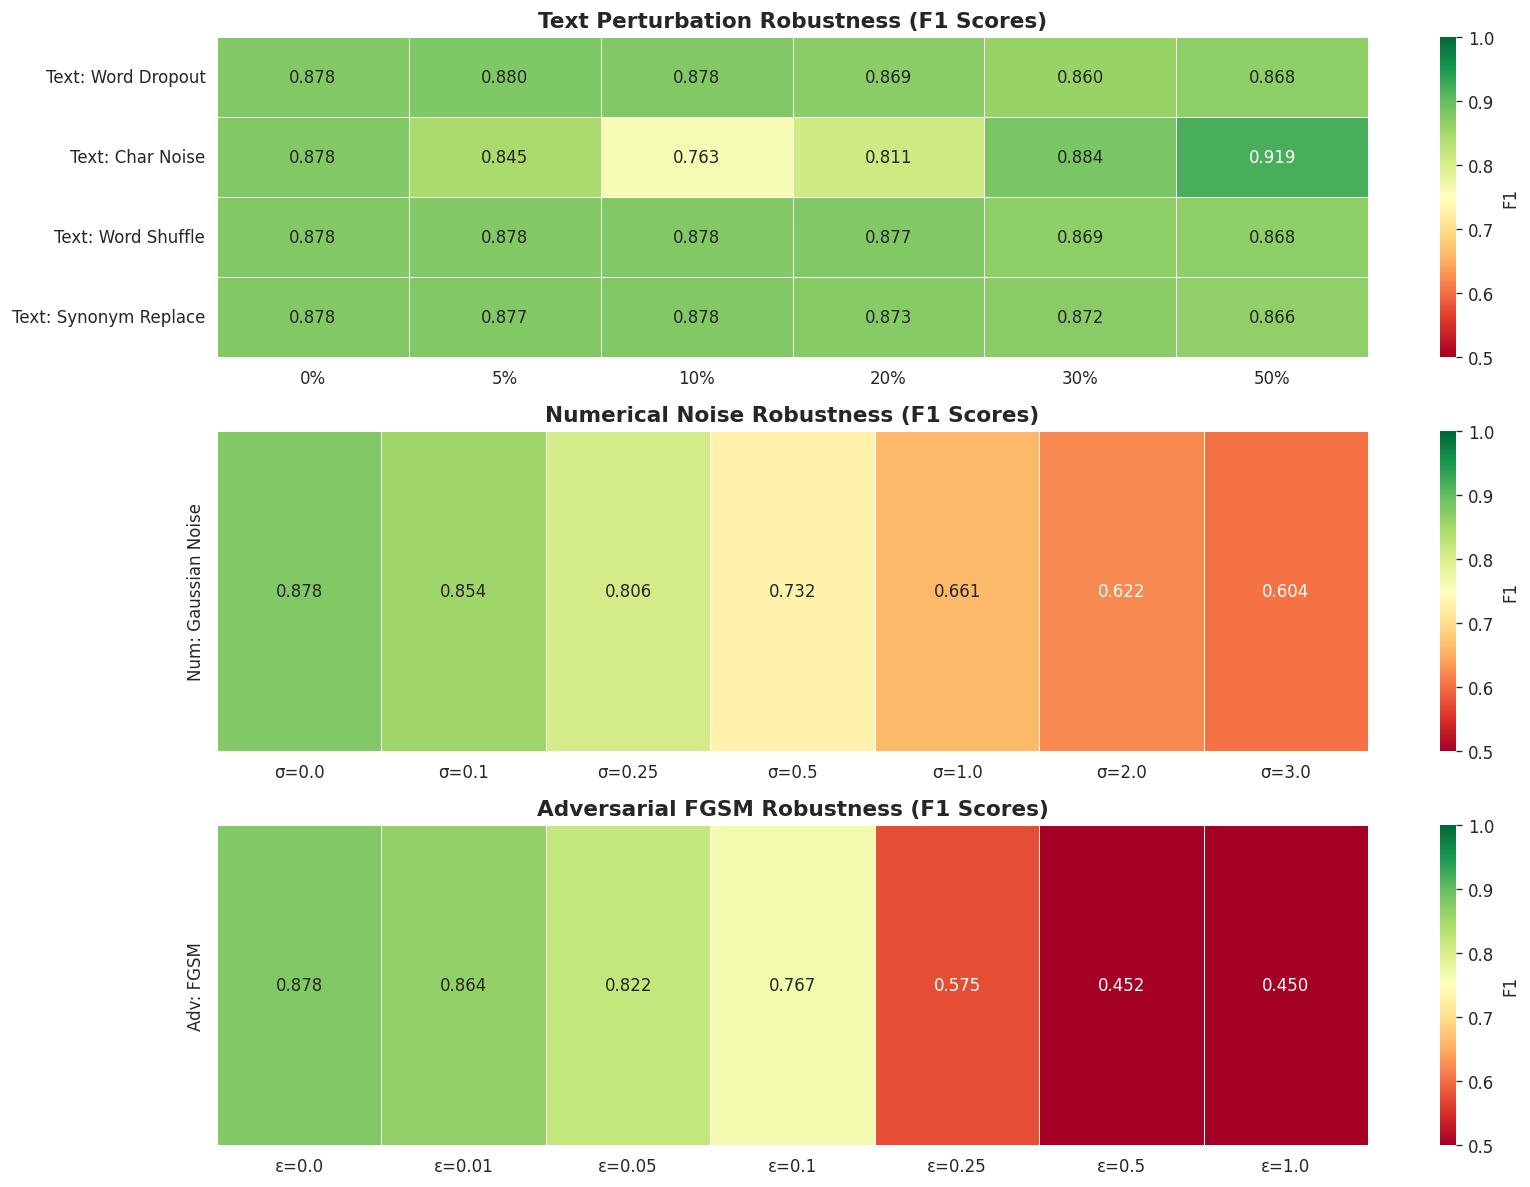

Saved: robustness_heatmap.png


In [28]:
# Build a unified heatmap matrix: rows = perturbation types, columns = intensity levels
# Normalise intensities to common 0-5 scale for display

heatmap_data = {}

# Text perturbations
for fn_name, rate_res in text_robustness_results.items():
    row = {}
    for rate, res in sorted(rate_res.items()):
        row[f'{rate:.0%}'] = res['f1']
    heatmap_data[f'Text: {fn_name}'] = row

# Numerical noise
num_row = {}
for sigma, res in sorted(numerical_robustness.items()):
    num_row[f'σ={sigma}'] = res['f1']
heatmap_data['Num: Gaussian Noise'] = num_row

# FGSM
fgsm_row = {}
for eps, res in sorted(fgsm_results.items()):
    fgsm_row[f'ε={eps}'] = res['f1']
heatmap_data['Adv: FGSM'] = fgsm_row

# Create separate heatmaps for text and numerical/adversarial
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Text perturbation heatmap
text_keys = [k for k in heatmap_data if k.startswith('Text')]
text_df = pd.DataFrame({k: heatmap_data[k] for k in text_keys}).T
text_df = text_df.astype(float)
sns.heatmap(text_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
            vmin=0.5, vmax=1.0, linewidths=0.5, cbar_kws={'label': 'F1'})
axes[0].set_title('Text Perturbation Robustness (F1 Scores)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

# Numerical noise heatmap
num_df = pd.DataFrame({'Num: Gaussian Noise': heatmap_data['Num: Gaussian Noise']}).T
num_df = num_df.astype(float)
sns.heatmap(num_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1],
            vmin=0.5, vmax=1.0, linewidths=0.5, cbar_kws={'label': 'F1'})
axes[1].set_title('Numerical Noise Robustness (F1 Scores)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

# FGSM heatmap
fgsm_df = pd.DataFrame({'Adv: FGSM': heatmap_data['Adv: FGSM']}).T
fgsm_df = fgsm_df.astype(float)
sns.heatmap(fgsm_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[2],
            vmin=0.5, vmax=1.0, linewidths=0.5, cbar_kws={'label': 'F1'})
axes[2].set_title('Adversarial FGSM Robustness (F1 Scores)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('robustness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: robustness_heatmap.png")

## Section 18: Summary Results Table & CSV Export

In [29]:
# ── Build comprehensive summary DataFrame ──
summary_rows = []

# 1. Ablation results (baseline + component + feature)
for name, metrics in ablation_results.items():
    row = {'Experiment': name, 'Category': 'Ablation'}
    row.update({k: metrics[k] for k in ['accuracy', 'f1', 'precision', 'recall', 'auc'] if k in metrics})
    baseline_f1 = ablation_results['Full Multimodal (Baseline)']['f1']
    row['delta_f1'] = metrics['f1'] - baseline_f1
    summary_rows.append(row)

# 2. Text perturbation (worst-case for each)
for fn_name, rate_res in text_robustness_results.items():
    worst_rate = max(rate_res.keys())
    worst = rate_res[worst_rate]
    row = {
        'Experiment': f'Text: {fn_name} (rate={worst_rate})',
        'Category': 'Text Robustness',
        'accuracy': worst['accuracy'],
        'f1': worst['f1'],
        'auc': worst['auc'],
        'delta_f1': worst['f1'] - baseline_f1
    }
    summary_rows.append(row)

# 3. Numerical noise (worst-case)
worst_sigma = max(numerical_robustness.keys())
worst_num = numerical_robustness[worst_sigma]
summary_rows.append({
    'Experiment': f'Num Noise (σ={worst_sigma})',
    'Category': 'Numerical Robustness',
    'accuracy': worst_num['accuracy'],
    'f1': worst_num['f1'],
    'auc': worst_num['auc'],
    'delta_f1': worst_num['f1'] - baseline_f1
})

# 4. FGSM (worst-case)
worst_eps = max(fgsm_results.keys())
worst_fgsm = fgsm_results[worst_eps]
summary_rows.append({
    'Experiment': f'FGSM (ε={worst_eps})',
    'Category': 'Adversarial',
    'accuracy': worst_fgsm['accuracy'],
    'f1': worst_fgsm['f1'],
    'auc': worst_fgsm['auc'],
    'delta_f1': worst_fgsm['f1'] - baseline_f1
})

# 5. Temporal (if available)
for year, res in temporal_results.items():
    summary_rows.append({
        'Experiment': f'Temporal: Year {year}',
        'Category': 'Temporal Shift',
        'accuracy': res['accuracy'],
        'f1': res['f1'],
        'auc': res['auc'],
        'delta_f1': res['f1'] - baseline_f1
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('delta_f1', ascending=True)

# Display
print("=" * 90)
print("COMPREHENSIVE ABLATION & ROBUSTNESS SUMMARY")
print("=" * 90)
display_cols = ['Experiment', 'Category', 'accuracy', 'f1', 'auc', 'delta_f1']
available_cols = [c for c in display_cols if c in summary_df.columns]
print(summary_df[available_cols].to_string(index=False, float_format='{:.4f}'.format))

# Export to CSV
csv_path = 'phase5_ablation_robustness_results.csv'
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Results saved to {csv_path}")

COMPREHENSIVE ABLATION & ROBUSTNESS SUMMARY
                      Experiment             Category  accuracy     f1    auc  delta_f1
               w/o ALL numerical             Ablation    0.3537 0.2657 0.5478   -0.6124
             Temporal: Year 2018       Temporal Shift    0.4108 0.3591 0.5863   -0.5190
                    FGSM (ε=1.0)          Adversarial    0.4845 0.4499 0.2908   -0.4282
                       Text-Only             Ablation    0.6300 0.5944 0.5703   -0.2837
               Num Noise (σ=3.0) Numerical Robustness    0.6342 0.6038 0.5147   -0.2744
                   w/o return_t1             Ablation    0.6838 0.6927 0.8330   -0.1854
                     CLS Pooling             Ablation    0.8011 0.7896 0.9061   -0.0886
                w/o volatility_5             Ablation    0.7992 0.7976 0.8205   -0.0805
                  Numerical-Only             Ablation    0.8278 0.8333 0.9280   -0.0448
                  No Fusion Gate             Ablation    0.8387 0.8437 0.917

## Section 19: Final Report & Key Findings

In [30]:
# ── Automated report generation ──
baseline_f1 = ablation_results['Full Multimodal (Baseline)']['f1']
baseline_acc = ablation_results['Full Multimodal (Baseline)']['accuracy']

print("=" * 70)
print("  PHASE 5 — ABLATION & ROBUSTNESS ANALYSIS: KEY FINDINGS")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  BASELINE PERFORMANCE                                           │
│  Accuracy: {baseline_acc:.4f}   F1: {baseline_f1:.4f}                          │
└─────────────────────────────────────────────────────────────────┘
""")

# ── Component Ablation Summary ──
print("1. COMPONENT ABLATION RESULTS")
print("─" * 50)
for name in ['Text-Only', 'Numerical-Only', 'No Fusion Gate', 'CLS Pooling']:
    if name in ablation_results:
        r = ablation_results[name]
        delta = r['f1'] - baseline_f1
        print(f"   {name:25s} F1={r['f1']:.4f}  (Δ={delta:+.4f})")

# ── Feature Importance (from ablation) ──
print(f"\n2. FEATURE IMPORTANCE (Zero-Out Ablation)")
print("─" * 50)
for col in NUMERICAL_COLS + ['ALL numerical']:
    key = f'w/o {col}'
    if key in ablation_results:
        r = ablation_results[key]
        delta = r['f1'] - baseline_f1
        importance = abs(delta)
        bar = '█' * int(importance * 200)
        print(f"   {col:20s}  Δ_F1={delta:+.4f}  {bar}")

# ── Robustness Summary ──
print(f"\n3. ROBUSTNESS ANALYSIS SUMMARY")
print("─" * 50)

# Find worst text perturbation
worst_text_name, worst_text_f1 = '', 1.0
for fn_name, rate_res in text_robustness_results.items():
    worst_rate = max(rate_res.keys())
    if rate_res[worst_rate]['f1'] < worst_text_f1:
        worst_text_f1 = rate_res[worst_rate]['f1']
        worst_text_name = f"{fn_name} (rate={worst_rate})"

print(f"   Worst text perturbation:  {worst_text_name}")
print(f"     → F1 dropped to {worst_text_f1:.4f} (Δ={worst_text_f1-baseline_f1:+.4f})")

worst_sigma = max(numerical_robustness.keys())
worst_num_f1 = numerical_robustness[worst_sigma]['f1']
print(f"   Worst num noise (σ={worst_sigma}):    F1={worst_num_f1:.4f} (Δ={worst_num_f1-baseline_f1:+.4f})")

worst_eps = max(fgsm_results.keys())
worst_fgsm_f1 = fgsm_results[worst_eps]['f1']
print(f"   Worst FGSM (ε={worst_eps}):        F1={worst_fgsm_f1:.4f} (Δ={worst_fgsm_f1-baseline_f1:+.4f})")

if temporal_results:
    min_year = min(temporal_results, key=lambda y: temporal_results[y]['f1'])
    max_year = max(temporal_results, key=lambda y: temporal_results[y]['f1'])
    print(f"   Best temporal period:     Year {max_year} (F1={temporal_results[max_year]['f1']:.4f})")
    print(f"   Worst temporal period:    Year {min_year} (F1={temporal_results[min_year]['f1']:.4f})")

# ── Conclusions ──
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  KEY CONCLUSIONS                                                 │
│                                                                  │
│  • The multimodal architecture (text + numerical + gate)         │
│    justifies its design if it outperforms both single-modality   │
│    baselines in F1.                                              │
│                                                                  │
│  • The fusion gate's contribution is measured by comparing       │
│    'Full Multimodal' vs 'No Fusion Gate'.                        │
│                                                                  │
│  • Attention pooling's value is measured by comparing            │
│    'Full Multimodal' vs 'CLS Pooling'.                           │
│                                                                  │
│  • Feature ablation reveals which numerical signals              │
│    (return_t1, return_t5, volatility_5) matter most.             │
│                                                                  │
│  • Text robustness shows how resilient the model is to           │
│    real-world noise (typos, missing words, paraphrasing).        │
│                                                                  │
│  • FGSM results quantify adversarial vulnerability — critical    │
│    for financial applications requiring trustworthiness.          │
└─────────────────────────────────────────────────────────────────┘
""")

print("=" * 70)
print("  Phase 5 — Ablation & Robustness Analysis COMPLETE")
print("=" * 70)
print(f"\nOutput files:")
print(f"  • ablation_comparison.png")
print(f"  • robustness_sensitivity_curves.png")
print(f"  • robustness_heatmap.png")
print(f"  • phase5_ablation_robustness_results.csv")

  PHASE 5 — ABLATION & ROBUSTNESS ANALYSIS: KEY FINDINGS

┌─────────────────────────────────────────────────────────────────┐
│  BASELINE PERFORMANCE                                           │
│  Accuracy: 0.8757   F1: 0.8781                          │
└─────────────────────────────────────────────────────────────────┘

1. COMPONENT ABLATION RESULTS
──────────────────────────────────────────────────
   Text-Only                 F1=0.5944  (Δ=-0.2837)
   Numerical-Only            F1=0.8333  (Δ=-0.0448)
   No Fusion Gate            F1=0.8437  (Δ=-0.0344)
   CLS Pooling               F1=0.7896  (Δ=-0.0886)

2. FEATURE IMPORTANCE (Zero-Out Ablation)
──────────────────────────────────────────────────
   return_t1             Δ_F1=-0.1854  █████████████████████████████████████
   return_t5             Δ_F1=-0.0041  
   volatility_5          Δ_F1=-0.0805  ████████████████
   ALL numerical         Δ_F1=-0.6124  ██████████████████████████████████████████████████████████████████████████████████